In this notebook, we compare the python and c++ implementations of static factorization.

In [1]:
import sys; sys.path.insert(0,"../..") # Allow import of agd from parent directory (useless if conda package installed)
#from Miscellaneous import TocTools; print(TocTools.displayTOC('HighAccuracy','FMM'))

In [2]:
from agd import Eikonal
from agd import Metrics
from agd.Metrics.Seismic import Hooke
from agd import FiniteDifferences as fd
from agd import LinearParallel as lp
from agd import AutomaticDifferentiation as ad
from agd.Plotting import savefig; #savefig.dirName = 'Figures/HighAccuracy'

In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
def LInfNorm(a): return np.max(np.abs(a))
def L1Norm(a):   return np.sum(np.abs(a))/a.size

In [82]:
'Key'=='Both'

False

### Isotropic - key

In [5]:
def PoincareCost(q):
    """
    Cost function defining the Poincare half plane model of the hyperbolic plane.
    """
    return 1/q[1]

In [27]:
dimx=100
hfmIn = Eikonal.dictIn({
    'model':'Isotropic2',
    'seed': [0.,1.5],
    'exportValues':1.,
    'factoringRadius':-1,
    'exportFactoring':1,
})
hfmIn.SetRect(sides=[[-0.5,0.5],[1,2]],dimx=dimx,sampleBoundary=True)
hfmIn.SetUniformTips((6,6))
    
X = hfmIn.Grid()
hfmIn['cost'] = PoincareCost(X)
seed = hfmIn['seed']
factor = Metrics.Isotropic(PoincareCost(seed))
seed_ = fd.as_field(seed,hfmIn.shape)
h = hfmIn['gridScale']

In [7]:
hfmOut = hfmIn.Run()

Field verbosity defaults to 1
Field order defaults to 1
Field seedRadius defaults to 2
Field factoringPointChoice defaults to Key
ComputeFactor : {0.00673401,0.00673401}
Fast marching solver completed in 0.078747 s.
Field geodesicSolver defaults to Discrete
Field geodesicStep defaults to 0.25
Field geodesicWeightThreshold defaults to 0.001
Field geodesicVolumeBound defaults to 8.45
Ended Geodesic Discrete Solver


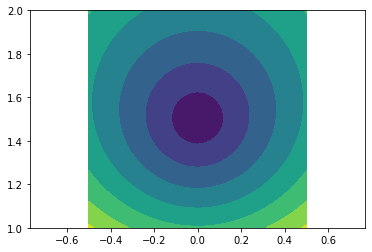

In [8]:
plt.contourf(*X,hfmOut['values']); plt.axis('equal');

In [9]:
LInfNorm(hfmOut['factoringValues']-factor.norm(X-seed_))

2.7755575615628914e-16

In [29]:
LInfNorm(hfmOut['factoringGradients']/h-factor.gradient(X-seed_))

4.163336342344337e-15

### Isotropic - both

In [70]:
def UnitCost(x): return np.ones_like(x[0])

def LinearCost(q):
    """
    Cost function defining the Poincare half plane model of the hyperbolic plane.
    """
    return q[1]

cost = LinearCost

In [71]:
dimx=100
hfmIn = Eikonal.dictIn({
    'model':'Isotropic2',
    'exportValues':1.,
    'factoringRadius':-1,
    'exportFactoring':1,
    'factoringPointChoice':'Both',
})
hfmIn.SetRect(sides=[[-0.5,0.5],[1,2]],dimx=dimx,sampleBoundary=True)
hfmIn.SetUniformTips((6,6))
    
X = hfmIn.Grid()
hfmIn['cost'] = cost(X)
seed = X[:,dimx//2,dimx//2]
hfmIn['seed']=seed
factor = Metrics.Isotropic(cost(seed))
seed_ = fd.as_field(seed,hfmIn.shape)
h = hfmIn['gridScale']

def factor(x):
    return 0.5*(cost(seed_) + cost(x)) * ad.Optimization.norm(x-seed_,axis=0)

In [72]:
hfmOut = hfmIn.Run()

Field verbosity defaults to 1
Field order defaults to 1
Field seedRadius defaults to 2
ComputeFactor : {0.0152025,0.0152025}
Fast marching solver completed in 0.066254 s.
Field geodesicSolver defaults to Discrete
Field geodesicStep defaults to 0.25
Field geodesicWeightThreshold defaults to 0.001
Field geodesicVolumeBound defaults to 8.45
Ended Geodesic Discrete Solver


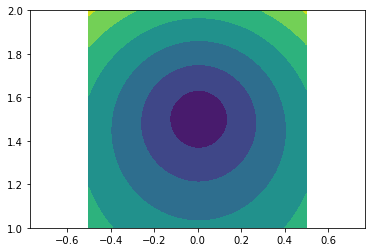

In [73]:
plt.contourf(*X,hfmOut['values']); plt.axis('equal');

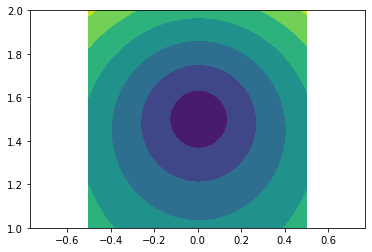

In [74]:
plt.contourf(*X,hfmOut['factoringValues']); plt.axis('equal');

In [75]:
LInfNorm(hfmOut['factoringValues'] - factor(X))

8.881784197001252e-16

In [76]:
X_ad = ad.Dense.identity(constant=X,shape_free=(2,))

In [77]:
factorGradient = factor(X_ad).gradient()

In [78]:
error = np.where(np.isnan(factorGradient),0,hfmOut['factoringGradients']/h - factorGradient)
LInfNorm(error)

2.9531932455029164e-14

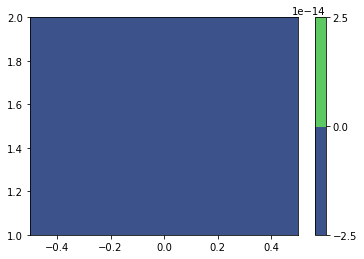

In [79]:
plt.contourf(*X,np.abs(error[1])>7e-6); plt.colorbar()